In [2]:
#1- imports et configuration 

import pandas as pd
import geopandas as gpd
import numpy as np
import zipfile
import os
import warnings

warnings.filterwarnings('ignore')
#chemin 
RAW = "../raw"
PROCESSED = "../processed"

REGISTRE     = os.path.join(RAW, "registre_coproprietes.csv")
DICTIONNAIRE = os.path.join(RAW, "rnic_dictionnaire_donnees.csv")
INSEE_ZIP    = os.path.join(RAW, "insee_logement.zip")
GEOMETRIES   = os.path.join(RAW, "communes_geometries.geojson")

# verification 
fichiers = {
    "Registre copropriétés" : REGISTRE,
    "Dictionnaire RNIC"     : DICTIONNAIRE,
    "INSEE logement (zip)"  : INSEE_ZIP,
    "Géométries communes"   : GEOMETRIES,
}
print(" verification des fichiers")
tous_presents = True
for nom, chemin in fichiers.items():
    existe = os.path.exists(chemin)
    statut = "(:://c'est bon)" if existe else " MANQUANT"
    taille = f"{os.path.getsize(chemin) / 1e6:.1f} Mo" if existe else ""
    print(f"  {statut}  {nom:30s}  {taille}")
    if not existe:
        tous_presents = False
print()
if tous_presents:
    print(" Tous les fichiers sont présents — pipeline prêt à lancer")
else:
    print(" Fichiers manquants — vérifier le dossier raw/")

 verification des fichiers
  (:://c'est bon)  Registre copropriétés           458.5 Mo
  (:://c'est bon)  Dictionnaire RNIC               0.0 Mo
  (:://c'est bon)  INSEE logement (zip)            25.5 Mo
  (:://c'est bon)  Géométries communes             32.5 Mo

 Tous les fichiers sont présents — pipeline prêt à lancer


In [3]:
#2- chargement du registre des coprpriétés 
print(" chargement du registre des copropriétés")
# lecture avec gestion de l'encodage
df_copro = pd.read_csv(
    REGISTRE,
    sep=",",
    encoding="utf-8",
    low_memory=False,
    on_bad_lines="skip"
)
print(f"  Lignes    : {len(df_copro):,}")
print(f"  Colonnes  : {len(df_copro.columns)}")
print()
# afficher les 5 premières lignes
print(" aperçu des données")
print(df_copro.columns.tolist()[:20])
print()
# apercu 3 premières lignes
print("3 premières lignes")
df_copro.head(3)

 chargement du registre des copropriétés
  Lignes    : 626,702
  Colonnes  : 72

 aperçu des données
['epci', 'commune', 'numero_d_immatriculation', 'date_d_immatriculation', 'date_de_la_derniere_maj', 'type_de_syndic_benevole_professionnel_non_connu', 'identification_du_representant_legal_raison_sociale_et_le_numer', 'raison_sociale_du_representant_legal', 'siret_du_representant_legal', 'code_ape', 'commune_du_representant_legal', 'mandat_en_cours_dans_la_copropriete', 'date_de_fin_du_dernier_mandat', 'nom_d_usage_de_la_copropriete', 'adresse_de_reference', 'numero_et_voie_adresse_de_reference', 'code_postal_adresse_de_reference', 'commune_adresse_de_reference', 'adresse_complementaire_1', 'adresse_complementaire_2']

3 premières lignes


,epci,commune,numero_d_immatriculation,date_d_immatriculation,date_de_la_derniere_maj,type_de_syndic_benevole_professionnel_non_connu,identification_du_representant_legal_raison_sociale_et_le_numer,raison_sociale_du_representant_legal,siret_du_representant_legal,code_ape,...,code_officiel_commune,nom_officiel_commune,code_officiel_arrondissement_commune,nom_officiel_arrondissement_commune,code_officiel_epci,nom_officiel_epci,code_officiel_departement,nom_officiel_departement,code_officiel_region,nom_officiel_region
0,246900724.0,69094,AA0002402,2017-09-21,2025-08-23,professionnel,JOSEPH BAUR IMMOBILIER 34473827300012,JOSEPH BAUR IMMOBILIER,34473827300012,6832A,...,69094,Grézieu-la-Varenne,69094,Grézieu-la-Varenne,246900724.0,CC des Vallons du Lyonnais (Ccvl),69,Rhône,84,Auvergne Rhône-Alpes
1,200046977.0,69385,AA0002576,2016-07-29,2025-08-23,professionnel,JOSEPH BAUR IMMOBILIER 34473827300012,JOSEPH BAUR IMMOBILIER,34473827300012,6832A,...,69123,Lyon,69385,Lyon - 5e arrondissement,200046977.0,Métropole de LYON,69,Rhône,84,Auvergne Rhône-Alpes
2,200046977.0,69381,AA0002659,2017-09-21,2025-08-23,professionnel,JOSEPH BAUR IMMOBILIER 34473827300012,JOSEPH BAUR IMMOBILIER,34473827300012,6832A,...,69123,Lyon,69381,Lyon - 1er arrondissement,200046977.0,Métropole de LYON,69,Rhône,84,Auvergne Rhône-Alpes


In [4]:
# 3 idnentification des colonnes d'intérêt
print(" identification des colonnes d'intérêt")
for i, col in enumerate(df_copro.columns.tolist()):
    print(f"  {i:02d}  {col}")
print( "Colonnes 24 à 67\n")
for i, col in enumerate(df_copro.columns.tolist()):
    if 24 <= i <= 67:
        print(f"  {i:02d}  {col}")

 identification des colonnes d'intérêt
  00  epci
  01  commune
  02  numero_d_immatriculation
  03  date_d_immatriculation
  04  date_de_la_derniere_maj
  05  type_de_syndic_benevole_professionnel_non_connu
  06  identification_du_representant_legal_raison_sociale_et_le_numer
  07  raison_sociale_du_representant_legal
  08  siret_du_representant_legal
  09  code_ape
  10  commune_du_representant_legal
  11  mandat_en_cours_dans_la_copropriete
  12  date_de_fin_du_dernier_mandat
  13  nom_d_usage_de_la_copropriete
  14  adresse_de_reference
  15  numero_et_voie_adresse_de_reference
  16  code_postal_adresse_de_reference
  17  commune_adresse_de_reference
  18  adresse_complementaire_1
  19  adresse_complementaire_2
  20  adresse_complementaire_3
  21  nombre_d_adresses_complementaires
  22  long
  23  lat
  24  date_du_reglement_de_copropriete
  25  residence_service
  26  syndicat_cooperatif
  27  syndicat_principal_ou_syndicat_secondaire
  28  si_secondaire_n_d_immatriculation_du_pri

In [5]:
#  4 — Nettoyage du registre des copropriétés
print(" nettoyage du registre des copropriétés")

# a/ garder les colonnes d'intérêt
cols_utiles = [
    'commune',
    'type_de_syndic_benevole_professionnel_non_connu',
    'raison_sociale_du_representant_legal',
    'nombre_total_de_lots',
    'nombre_de_lots_a_usage_d_habitation',
    'nombre_de_lots_de_stationnement',
    'nom_officiel_departement',
    'nom_officiel_region',
    'nom_officiel_arrondissement_commune'
]
df_copro_clean = df_copro[cols_utiles].copy()

# renomer les colonnes pour simplifier 

df_copro_clean.columns = [
    'code_commune',
    'type_syndic',
    'nom_syndic',
    'nb_lots_total',
    'nb_lots_habitation',
    'nb_lots_stationnement',
    'departement',
    'region',
    'arrondissement'
]
print(f"Colonnes gardées : {len(df_copro_clean.columns)}")
print(f"Lignes avant nettoyage : {len(df_copro_clean):,}")

# b/ Supprimer les lignes sans code commune
df_copro_clean = df_copro_clean.dropna(subset=['code_commune'])
print(f"Lignes après suppression NaN commune : {len(df_copro_clean):,}")

# c/  Convertir les lots en numérique
for col in ['nb_lots_total', 'nb_lots_habitation', 'nb_lots_stationnement']:
    df_copro_clean[col] = pd.to_numeric(df_copro_clean[col], errors='coerce').fillna(0)

# d/ Supprimer les copros avec 0 lots
avant = len(df_copro_clean)
df_copro_clean = df_copro_clean[df_copro_clean['nb_lots_total'] > 0]
print(f"Lignes après suppression lots=0 : {len(df_copro_clean):,}")
print(f"  (supprimé {avant - len(df_copro_clean):,} lignes invalides)")

# e/ Nettoyer le nom syndic
df_copro_clean['nom_syndic'] = (
    df_copro_clean['nom_syndic']
    .astype(str)
    .str.strip()
    .str.upper()
)

# f/ Normaliser le type de syndic
df_copro_clean['type_syndic'] = (
    df_copro_clean['type_syndic']
    .astype(str)
    .str.strip()
    .str.lower()
)

print()
print("// Types de syndic \\")
print(df_copro_clean['type_syndic'].value_counts())

print()
print("// Aperçu final \\")
print(df_copro_clean.head(3).to_string())


 nettoyage du registre des copropriétés
Colonnes gardées : 9
Lignes avant nettoyage : 626,702
Lignes après suppression NaN commune : 626,702
Lignes après suppression lots=0 : 626,679
  (supprimé 23 lignes invalides)

// Types de syndic \
type_syndic
professionnel    308219
non connu        280480
bénévole          37980
Name: count, dtype: int64

// Aperçu final \
  code_commune    type_syndic              nom_syndic  nb_lots_total  nb_lots_habitation  nb_lots_stationnement departement                region             arrondissement
0        69094  professionnel  JOSEPH BAUR IMMOBILIER          202.0                67.0                   72.0       Rhône  Auvergne Rhône-Alpes         Grézieu-la-Varenne
1        69385  professionnel  JOSEPH BAUR IMMOBILIER           16.0                 7.0                    0.0       Rhône  Auvergne Rhône-Alpes   Lyon - 5e arrondissement
2        69381  professionnel  JOSEPH BAUR IMMOBILIER           23.0                17.0                    0.0   

In [6]:
#  5 — Agrégation par commune

# a/ Métriques de base par commune 
agg_commune = df_copro_clean.groupby('code_commune').agg(
    nb_coproprietes        = ('nb_lots_total',        'count'),
    taille_moy_copro       = ('nb_lots_total',        'mean'),
    nb_lots_total_commune  = ('nb_lots_total',        'sum'),
    nb_lots_stationnement  = ('nb_lots_stationnement','sum'),
    departement            = ('departement',          'first'),
    region                 = ('region',               'first'),
).reset_index()

# b/ Indice de concentration syndic
# Pour chaque commune : quel % des copros est géré par le même syndic dominant ?
def concentration_syndic(groupe):
    # Filtrer les syndics professionnels uniquement
    pros = groupe[groupe['type_syndic'] == 'professionnel']['nom_syndic']
    if len(pros) == 0:
        return 0.0, "aucun syndic professionnel"
    # Syndic le plus fréquent
    syndic_dominant = pros.value_counts().index[0]
    part_dominant   = pros.value_counts().iloc[0] / len(groupe)
    return round(part_dominant, 4), syndic_dominant
print("Calcul de l'indice de concentration syndic...")
resultats_syndic = (
    df_copro_clean
    .groupby('code_commune')
    .apply(concentration_syndic)
    .reset_index()
)
resultats_syndic.columns = ['code_commune', 'syndic_result']
resultats_syndic['indice_concentration_syndic'] = resultats_syndic['syndic_result'].apply(lambda x: x[0])
resultats_syndic['syndic_dominant']             = resultats_syndic['syndic_result'].apply(lambda x: x[1])
resultats_syndic = resultats_syndic.drop(columns=['syndic_result'])

# c/ fusion 
agg_commune = agg_commune.merge(resultats_syndic, on='code_commune', how='left')
# d/ arrondir 
agg_commune['taille_moy_copro'] = agg_commune['taille_moy_copro'].round(1)

print(f"Communes dans le registre : {len(agg_commune):,}")
print()
print("=== Aperçu ===")
print(agg_commune.head(5).to_string())
print()
print("=== Statistiques ===")
print(agg_commune[['nb_coproprietes','taille_moy_copro','indice_concentration_syndic']].describe().round(2))

Calcul de l'indice de concentration syndic...
Communes dans le registre : 13,158

=== Aperçu ===
  code_commune  nb_coproprietes  taille_moy_copro  nb_lots_total_commune  nb_lots_stationnement departement                region  indice_concentration_syndic                    syndic_dominant
0        01001                1               2.0                    2.0                    0.0         Ain  Auvergne Rhône-Alpes                       0.0000         aucun syndic professionnel
1        01004              196              30.7                 6016.0                 2186.0         Ain  Auvergne Rhône-Alpes                       0.2959                   BUGEY IMMOBILIER
2        01005               13              31.5                  410.0                  179.0         Ain  Auvergne Rhône-Alpes                       0.1538                        FONCIA LYON
3        01006                2               2.5                    5.0                    0.0         Ain  Auvergne Rhône-Alp

In [7]:
#  6 / Chargement du fichier INSEE logement

print(" chargement du fichier INSEE logement")
with zipfile.ZipFile(INSEE_ZIP, 'r') as z:
    print("Fichiers dans le zip :")
    for nom in z.namelist():
        print(f"  {nom}")

 chargement du fichier INSEE logement
Fichiers dans le zip :
  base-ic-logement-2020.CSV
  meta_base-ic-logement-2020.CSV


In [8]:
#  7 / Chargement INSEE logement
print(" chargement du fichier INSEE logement")
with zipfile.ZipFile(INSEE_ZIP, 'r') as z:
    with z.open('base-ic-logement-2020.CSV') as f:
        df_insee = pd.read_csv(f, sep=';', encoding='utf-8', low_memory=False)

print(f"  Lignes   : {len(df_insee):,}")
print(f"  Colonnes : {len(df_insee.columns)}")
print()

# Chercher les colonnes qui nous intéressent
mots_cles = ['voit', 'hlm', 'rp', 'log', 'com']
print("=== Colonnes potentiellement utiles ===")
for col in df_insee.columns:
    if any(m in col.lower() for m in mots_cles):
        print(f"  {col}")

 chargement du fichier INSEE logement
  Lignes   : 49,273
  Colonnes : 96

=== Colonnes potentiellement utiles ===
  COM
  P20_LOG
  P20_RP
  P20_LOGVAC
  P20_RP_1P
  P20_RP_2P
  P20_RP_3P
  P20_RP_4P
  P20_RP_5PP
  P20_NBPI_RP
  P20_RPMAISON
  P20_NBPI_RPMAISON
  P20_RPAPPART
  P20_NBPI_RPAPPART
  P20_RP_M30M2
  P20_RP_3040M2
  P20_RP_4060M2
  P20_RP_6080M2
  P20_RP_80100M2
  P20_RP_100120M2
  P20_RP_120M2P
  P20_RP_ACHTOT
  P20_RP_ACH19
  P20_RP_ACH45
  P20_RP_ACH70
  P20_RP_ACH90
  P20_RP_ACH05
  P20_RP_ACH17
  P20_RPMAISON_ACHTOT
  P20_RPMAISON_ACH19
  P20_RPMAISON_ACH45
  P20_RPMAISON_ACH70
  P20_RPMAISON_ACH90
  P20_RPMAISON_ACH05
  P20_RPMAISON_ACH17
  P20_RPAPPART_ACHTOT
  P20_RPAPPART_ACH19
  P20_RPAPPART_ACH45
  P20_RPAPPART_ACH70
  P20_RPAPPART_ACH90
  P20_RPAPPART_ACH05
  P20_RPAPPART_ACH17
  P20_NBPI_RP_ANEM0002
  P20_NBPI_RP_ANEM0204
  P20_NBPI_RP_ANEM0509
  P20_NBPI_RP_ANEM10P
  P20_RP_PROP
  P20_RP_LOC
  P20_RP_LOCHLMV
  P20_RP_GRAT
  P20_NPER_RP
  P20_NPER_RP_PROP
  P2

In [9]:
# 7. b  — Trouver colonnes voitures et HLM
# ============================================================

print(" Colonnes voitures")
for col in df_insee.columns:
    if 'voit' in col.lower():
        print(f"  {col}")

print()
print(" Colonnes HLM / logement social ")
for col in df_insee.columns:
    if 'hlm' in col.lower():
        print(f"  {col}")

print()
print(" Aperçu des 3 premières lignes ")
print(df_insee[['COM']].head(3))

 Colonnes voitures
  P20_RP_VOIT1P
  P20_RP_VOIT1
  P20_RP_VOIT2P

 Colonnes HLM / logement social 
  P20_RP_LOCHLMV
  P20_NPER_RP_LOCHLMV
  P20_ANEM_RP_LOCHLMV

 Aperçu des 3 premières lignes 
     COM
0  01001
1  01002
2  01004


In [10]:
# 8 / Nettoyage INSEE logement


print("Nettoyage INSEE logement \n")

# a. Garder uniquement les colonnes utiles
cols_insee = [
    'COM',
    'P20_RP',           # total résidences principales
    'P20_RPAPPART',     # appartements
    'P20_RPMAISON',     # maisons
    'P20_RP_VOIT1P',    # ménages avec au moins 1 voiture
    'P20_RP_LOCHLMV',   # logements HLM
]

df_insee_clean = df_insee[cols_insee].copy()

# b. Renommer pour clarté
df_insee_clean.columns = [
    'code_commune',
    'nb_residences_principales',
    'nb_appartements',
    'nb_maisons',
    'nb_menages_avec_voiture',
    'nb_logements_hlm',
]

# c. Code commune en string sur 5 caractères
df_insee_clean['code_commune'] = (
    df_insee_clean['code_commune']
    .astype(str)
    .str.strip()
    .str.zfill(5)
)

# d. Convertir toutes les colonnes numériques
cols_num = [
    'nb_residences_principales',
    'nb_appartements',
    'nb_maisons',
    'nb_menages_avec_voiture',
    'nb_logements_hlm',
]
for col in cols_num:
    df_insee_clean[col] = pd.to_numeric(
        df_insee_clean[col], errors='coerce'
    ).fillna(0)

# e. Supprimer lignes sans résidences principales
df_insee_clean = df_insee_clean[
    df_insee_clean['nb_residences_principales'] > 0
]

# f. Calculer les variables de scoring
df_insee_clean['taux_motorisation'] = (
    df_insee_clean['nb_menages_avec_voiture'] /
    df_insee_clean['nb_residences_principales']
).round(4)

df_insee_clean['part_appartements'] = (
    df_insee_clean['nb_appartements'] /
    df_insee_clean['nb_residences_principales']
).round(4)

df_insee_clean['part_hlm'] = (
    df_insee_clean['nb_logements_hlm'] /
    df_insee_clean['nb_residences_principales']
).round(4)

print(f"Communes INSEE : {len(df_insee_clean):,}")
print()
print("=== Aperçu ===")
print(df_insee_clean.head(3).to_string())
print()
print(" Statistiques variables de scoring ")
print(df_insee_clean[[
    'taux_motorisation',
    'part_appartements',
    'part_hlm'
]].describe().round(3))

Nettoyage INSEE logement 

Communes INSEE : 49,104

=== Aperçu ===
  code_commune  nb_residences_principales  nb_appartements  nb_maisons  nb_menages_avec_voiture  nb_logements_hlm  taux_motorisation  part_appartements  part_hlm
0        01001                 328.879202         8.197240  320.681962               319.775730         12.839683             0.9723             0.0249    0.0390
1        01002                 110.875756         1.688471  109.187285               105.755796          0.000000             0.9538             0.0152    0.0000
2        01004                 782.410125       458.693717  296.425871               645.126238        129.021624             0.8245             0.5863    0.1649

 Statistiques variables de scoring 
       taux_motorisation  part_appartements   part_hlm
count          49104.000          49104.000  49104.000
mean               0.874              0.239      0.088
std                0.139              0.315      0.164
min                0.000    

In [11]:
#  9 — Fusion registre copropriétés + INSEE logement
print("//** Fusion des datasets **\\ \n")

# Fusion sur le code commune
df_fusion = agg_commune.merge(
    df_insee_clean,
    on='code_commune',
    how='inner'
)

print(f"Communes dans le registre copros  : {len(agg_commune):,}")
print(f"Communes dans l'INSEE logement    : {len(df_insee_clean):,}")
print(f"Communes après fusion             : {len(df_fusion):,}")
print()
print("=== Aperçu ===")
print(df_fusion.head(3).to_string())
print()
print("=== Colonnes disponibles ===")
for col in df_fusion.columns:
    print(f"  {col}")

//** Fusion des datasets **\ 

Communes dans le registre copros  : 13,158
Communes dans l'INSEE logement    : 49,104
Communes après fusion             : 27,159

=== Aperçu ===
  code_commune  nb_coproprietes  taille_moy_copro  nb_lots_total_commune  nb_lots_stationnement departement                region  indice_concentration_syndic             syndic_dominant  nb_residences_principales  nb_appartements  nb_maisons  nb_menages_avec_voiture  nb_logements_hlm  taux_motorisation  part_appartements  part_hlm
0        01001                1               2.0                    2.0                    0.0         Ain  Auvergne Rhône-Alpes                       0.0000  aucun syndic professionnel                 328.879202         8.197240  320.681962               319.775730         12.839683             0.9723             0.0249    0.0390
1        01004              196              30.7                 6016.0                 2186.0         Ain  Auvergne Rhône-Alpes                       0.29

In [12]:
#  9 . a/ — Agrégation INSEE au niveau commune + Fusion
print("=== Agrégation INSEE au niveau commune ===\n")

# 1. Additionner tous les IRIS d'une même commune
df_insee_commune = df_insee_clean.groupby('code_commune').agg(
    nb_residences_principales = ('nb_residences_principales', 'sum'),
    nb_appartements           = ('nb_appartements',           'sum'),
    nb_maisons                = ('nb_maisons',                'sum'),
    nb_menages_avec_voiture   = ('nb_menages_avec_voiture',   'sum'),
    nb_logements_hlm          = ('nb_logements_hlm',          'sum'),
).reset_index()

# 2. Recalculer les ratios sur les totaux commune
df_insee_commune['taux_motorisation'] = (
    df_insee_commune['nb_menages_avec_voiture'] /
    df_insee_commune['nb_residences_principales']
).round(4)

df_insee_commune['part_appartements'] = (
    df_insee_commune['nb_appartements'] /
    df_insee_commune['nb_residences_principales']
).round(4)

df_insee_commune['part_hlm'] = (
    df_insee_commune['nb_logements_hlm'] /
    df_insee_commune['nb_residences_principales']
).round(4)

print(f"Communes INSEE après agrégation : {len(df_insee_commune):,}")

# 3. Fusion avec le registre copropriétés
df_fusion = agg_commune.merge(
    df_insee_commune,
    on='code_commune',
    how='inner'
)

print(f"Communes après fusion           : {len(df_fusion):,}")
print()

# Vérifier qu'il n'y a plus de doublons
doublons = df_fusion['code_commune'].duplicated().sum()
print(f"Doublons restants : {doublons}")
print()
print("=== Aperçu ===")
print(df_fusion[['code_commune','nb_coproprietes','taille_moy_copro',
                  'taux_motorisation','part_appartements','part_hlm']].head(5).to_string())

=== Agrégation INSEE au niveau commune ===

Communes INSEE après agrégation : 34,974
Communes après fusion           : 13,067

Doublons restants : 0

=== Aperçu ===
  code_commune  nb_coproprietes  taille_moy_copro  taux_motorisation  part_appartements  part_hlm
0        01001                1               2.0             0.9723             0.0249    0.0390
1        01004              196              30.7             0.8451             0.5668    0.2218
2        01005               13              31.5             0.9660             0.2459    0.0924
3        01006                2               2.5             0.9649             0.0351    0.0175
4        01007               11               6.6             0.9497             0.1522    0.0908


In [13]:
# 10 /  Normalisation et calcul du score
from sklearn.preprocessing import MinMaxScaler

print("//** Calcul du scoring **\\\n")

# 1. Variables et poids
variables = [
    'taille_moy_copro',
    'taux_motorisation',
    'part_appartements',
    'indice_concentration_syndic',
    'part_hlm'
]

poids = [0.25, 0.20, 0.20, 0.20, 0.15]

# 2. Normalisation Min-Max (0 à 1)
scaler = MinMaxScaler()
df_norm = df_fusion.copy()
df_norm[variables] = scaler.fit_transform(df_fusion[variables])

# 3. Calcul du score pondéré sur 100
df_norm['score_potentiel'] = (
    df_norm['taille_moy_copro']            * poids[0] +
    df_norm['taux_motorisation']           * poids[1] +
    df_norm['part_appartements']           * poids[2] +
    df_norm['indice_concentration_syndic'] * poids[3] +
    df_norm['part_hlm']                   * poids[4]
) * 100

df_norm['score_potentiel'] = df_norm['score_potentiel'].round(2)

# 4. Ajouter le score dans df_fusion
df_fusion['score_potentiel'] = df_norm['score_potentiel']

print("=== Top 20 communes ===")
top20 = df_fusion.nlargest(20, 'score_potentiel')[[
    'code_commune', 'region', 'departement',
    'nb_coproprietes', 'taille_moy_copro',
    'score_potentiel', 'syndic_dominant'
]]
print(top20.to_string(index=False))

//** Calcul du scoring **\

=== Top 20 communes ===
code_commune                  region       departement  nb_coproprietes  taille_moy_copro  score_potentiel                            syndic_dominant
       76322               Normandie    Seine-Maritime               35              87.4            59.30                           FONCIA NORMANDIE
       65040               Occitanie   Hautes-Pyrénées                1             291.0            57.59                      CITYA CARNOT SYNDGEST
       28218     Centre-Val de Loire      Eure-et-Loir               37             131.8            55.27                              SA LP GESTION
       93030           Ile-de-France Seine-Saint-Denis               32             121.6            53.88                     FONCIA CHADEFAUX LECOQ
       21663 Bourgogne-Franche-Comté         Côte-d'Or                1               9.0            53.75 OFFICE PUBLIC DE L HABITAT DE LA COTE D OR
       62610         Hauts de France     Pas-de-

In [14]:
#  11 — Sauvegarde des fichiers de livraison
print("//** Sauvegarde des fichiers de livraison **\\\n")
# a. Charger les géométries
print("Chargement des géométries...")
gdf_communes = gpd.read_file(GEOMETRIES)
print(f"  Communes dans le GeoJSON : {len(gdf_communes):,}")
print(f"  Colonnes : {gdf_communes.columns.tolist()}")

//** Sauvegarde des fichiers de livraison **\

Chargement des géométries...
  Communes dans le GeoJSON : 35,074
  Colonnes : ['code', 'nom', 'departement', 'region', 'commune', 'plm', 'epci', 'geometry']


In [15]:

#  12 / Fusion géométries + Sauvegarde finale


print("=== Fusion avec géométries ===\n")

# a. Renommer la colonne code pour la jointure
gdf_communes = gdf_communes.rename(columns={'code': 'code_commune'})

# b. Fusion
gdf_final = gdf_communes.merge(
    df_fusion,
    on='code_commune',
    how='inner'
)

print(f"Communes avec géométrie + score : {len(gdf_final):,}")
print()

# c. Garder uniquement les colonnes utiles pour la livraison
cols_livraison = [
    'code_commune',
    'nom',
    'departement_y',
    'region_y',
    'score_potentiel',
    'nb_coproprietes',
    'taille_moy_copro',
    'taux_motorisation',
    'part_appartements',
    'indice_concentration_syndic',
    'part_hlm',
    'syndic_dominant',
    'nb_lots_stationnement',
    'geometry'
]

# Renommer après sélection pour clarté
gdf_final = gdf_final[cols_livraison].rename(columns={
    'departement_y': 'departement',
    'region_y': 'region',
    'nom': 'nom_commune'
})
# d. Sauvegarder CSV (sans géométrie pour Dev)
chemin_csv = os.path.join(PROCESSED, 'communes_scored.csv')
gdf_final.drop(columns=['geometry']).to_csv(
    chemin_csv, index=False, encoding='utf-8'
)
print(f"✅ CSV sauvegardé : {chemin_csv}")

# e. Sauvegarder GeoJSON (avec géométrie pour la carte)
chemin_geojson = os.path.join(PROCESSED, 'communes_scored.geojson')
gdf_final.to_file(chemin_geojson, driver='GeoJSON')
print(f"✅ GeoJSON sauvegardé : {chemin_geojson}")

print()
print("=== Résumé final ===")
print(f"  Communes scorées     : {len(gdf_final):,}")
print(f"  Score min            : {gdf_final['score_potentiel'].min():.2f}")
print(f"  Score max            : {gdf_final['score_potentiel'].max():.2f}")
print(f"  Score moyen          : {gdf_final['score_potentiel'].mean():.2f}")
print()
print(" Top 5 final")
print(gdf_final.nlargest(5, 'score_potentiel')[[
    'nom_commune', 'departement', 'score_potentiel', 'syndic_dominant'
]].to_string(index=False))


=== Fusion avec géométries ===

Communes avec géométrie + score : 13,061

✅ CSV sauvegardé : ../processed\communes_scored.csv
✅ GeoJSON sauvegardé : ../processed\communes_scored.geojson

=== Résumé final ===
  Communes scorées     : 13,061
  Score min            : 7.67
  Score max            : 59.30
  Score moyen          : 27.18

 Top 5 final
       nom_commune       departement  score_potentiel                            syndic_dominant
 Le Grand-Quevilly    Seine-Maritime            59.30                           FONCIA NORMANDIE
  Aspin-en-Lavedan   Hautes-Pyrénées            57.59                      CITYA CARNOT SYNDGEST
              Lucé      Eure-et-Loir            55.27                              SA LP GESTION
             Dugny Seine-Saint-Denis            53.88                     FONCIA CHADEFAUX LECOQ
Venarey-les-Laumes         Côte-d'Or            53.75 OFFICE PUBLIC DE L HABITAT DE LA COTE D OR


In [16]:
print(gdf_final.columns.tolist())

['code_commune', 'nom_commune', 'departement', 'region', 'score_potentiel', 'nb_coproprietes', 'taille_moy_copro', 'taux_motorisation', 'part_appartements', 'indice_concentration_syndic', 'part_hlm', 'syndic_dominant', 'nb_lots_stationnement', 'geometry']


✅ Graphiques sauvegardés : ../processed\kpis_graphiques.png


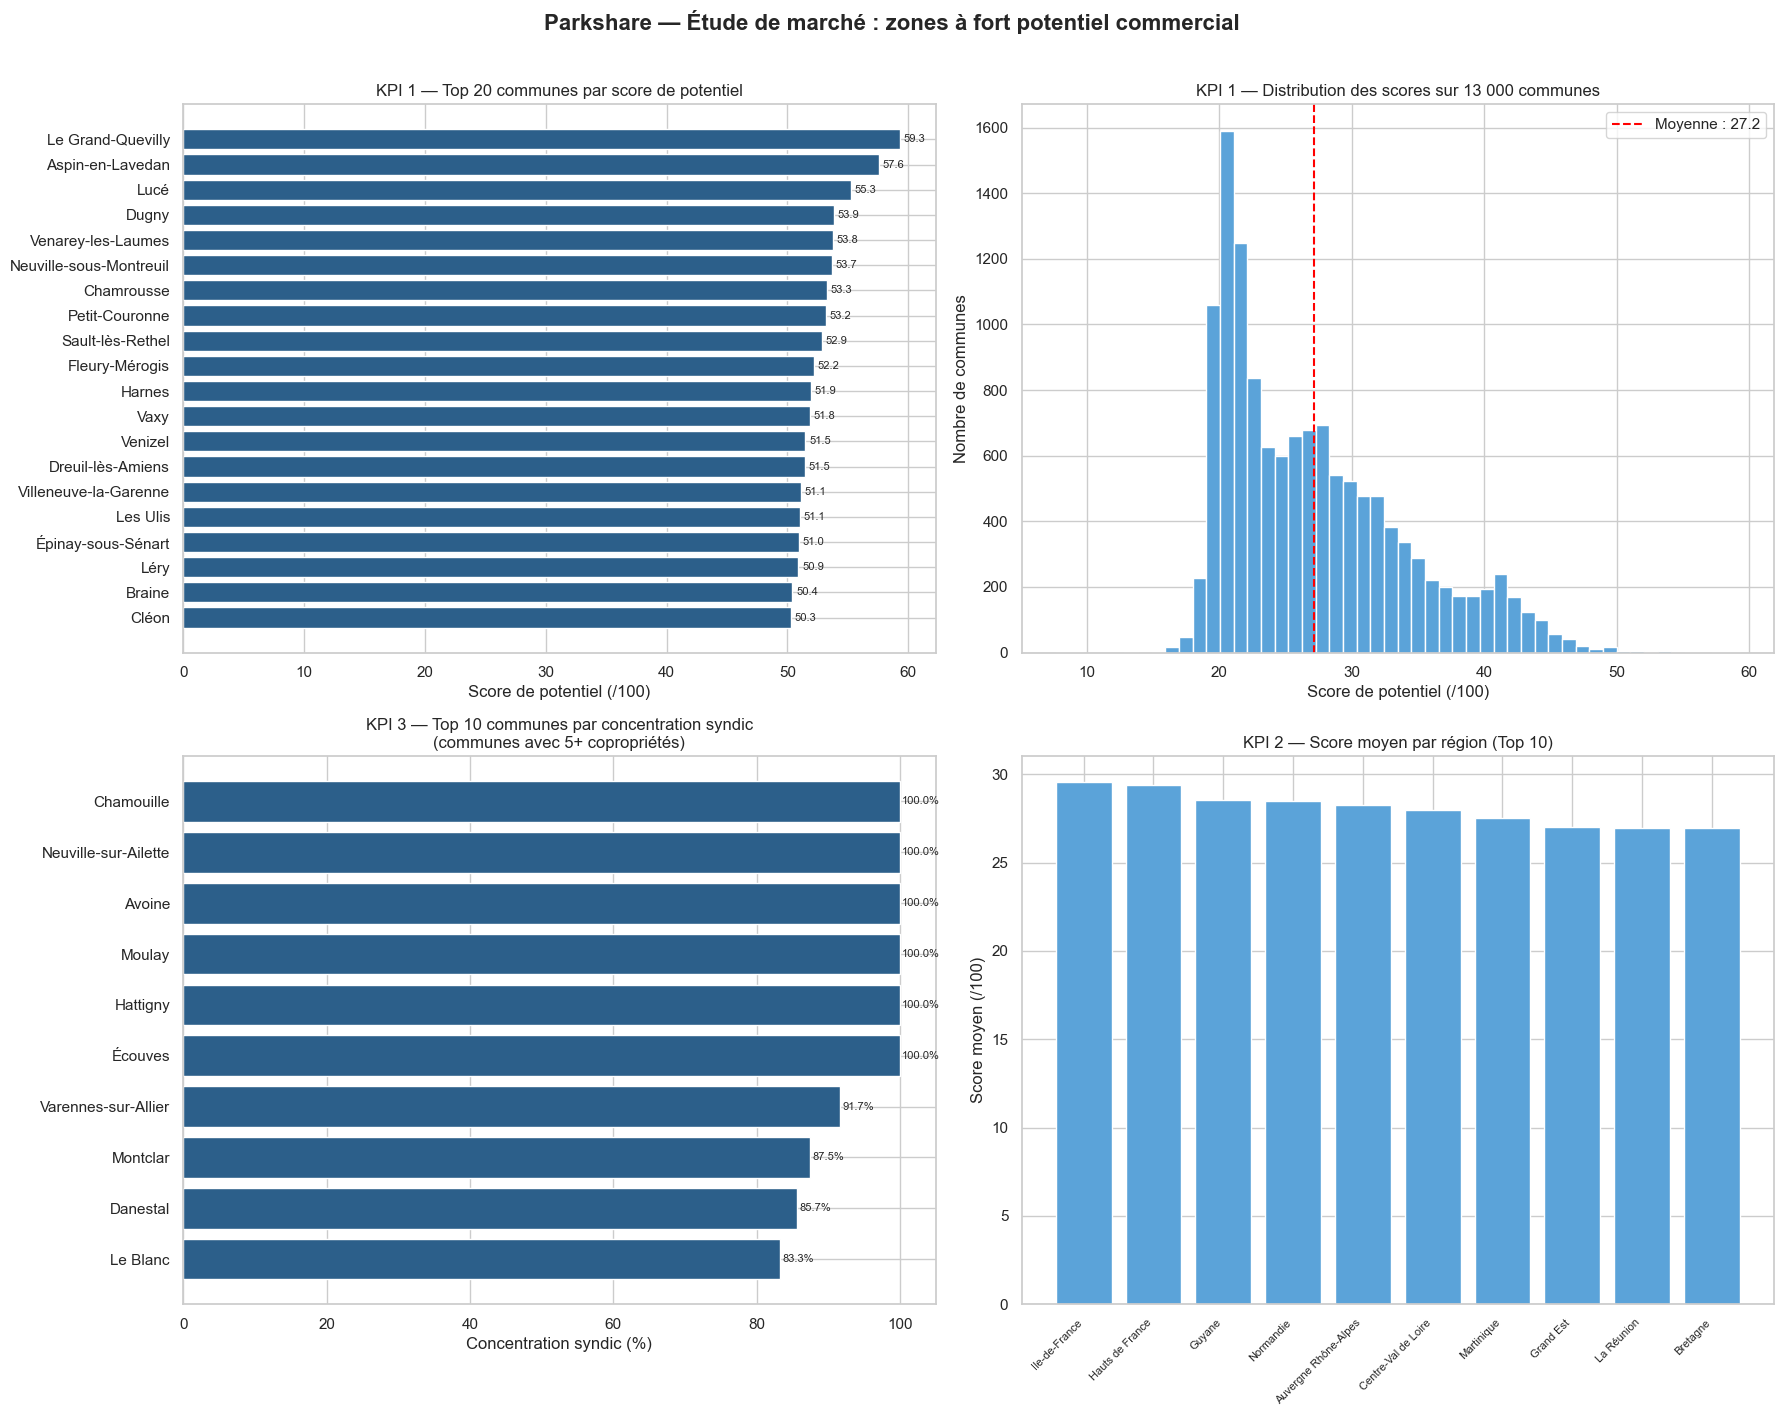

In [17]:

#  13 / Graphiques KPIs


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")
couleur_principale = "#2C5F8A"
couleur_secondaire = "#5BA3D9"

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(
    "Parkshare — Étude de marché : zones à fort potentiel commercial",
    fontsize=16, fontweight='bold', y=1.01
)

# ── Graphique 1 : Top 20 communes par score ──
ax1 = axes[0, 0]
top20 = gdf_final.nlargest(20, 'score_potentiel')
ax1.barh(
    top20['nom_commune'],
    top20['score_potentiel'],
    color=couleur_principale
)
ax1.set_xlabel("Score de potentiel (/100)")
ax1.set_title("KPI 1 — Top 20 communes par score de potentiel")
ax1.invert_yaxis()
for i, v in enumerate(top20['score_potentiel']):
    ax1.text(v + 0.3, i, f"{v:.1f}", va='center', fontsize=8)

# ── Graphique 2 : Distribution des scores ──
ax2 = axes[0, 1]
ax2.hist(
    gdf_final['score_potentiel'],
    bins=50,
    color=couleur_secondaire,
    edgecolor='white'
)
ax2.axvline(
    gdf_final['score_potentiel'].mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f"Moyenne : {gdf_final['score_potentiel'].mean():.1f}"
)
ax2.set_xlabel("Score de potentiel (/100)")
ax2.set_ylabel("Nombre de communes")
ax2.set_title("KPI 1 — Distribution des scores sur 13 000 communes")
ax2.legend()

# ── Graphique 3 : Top 10 concentration syndic (communes avec 5+ copros) ──
ax3 = axes[1, 0]
top10_syndic = (
    gdf_final[
        (gdf_final['indice_concentration_syndic'] > 0) &
        (gdf_final['nb_coproprietes'] >= 5)        # filtre communes significatives
    ]
    .nlargest(10, 'indice_concentration_syndic')
)
ax3.barh(
    top10_syndic['nom_commune'],
    top10_syndic['indice_concentration_syndic'] * 100,
    color=couleur_principale
)
ax3.set_xlabel("Concentration syndic (%)")
ax3.set_title("KPI 3 — Top 10 communes par concentration syndic\n(communes avec 5+ copropriétés)")
ax3.invert_yaxis()
for i, v in enumerate(top10_syndic['indice_concentration_syndic'] * 100):
    ax3.text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=8)

# ── Graphique 4 : Score moyen par région ──
ax4 = axes[1, 1]
score_region = (
    gdf_final.groupby('region')['score_potentiel']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
ax4.bar(
    range(len(score_region)),
    score_region.values,
    color=couleur_secondaire
)
ax4.set_xticks(range(len(score_region)))
ax4.set_xticklabels(score_region.index, rotation=45, ha='right', fontsize=8)
ax4.set_ylabel("Score moyen (/100)")
ax4.set_title("KPI 2 — Score moyen par région (Top 10)")

plt.tight_layout()

# Sauvegarder
chemin_graphique = os.path.join(PROCESSED, 'kpis_graphiques.png')
plt.savefig(chemin_graphique, dpi=150, bbox_inches='tight')
print(f"✅ Graphiques sauvegardés : {chemin_graphique}")
plt.show()

In [19]:
# KPI 3 recalculé — Concentration syndic par département (version rapide)

print("Calcul KPI 3 — Concentration syndic par département...")

# 1. Récupérer département depuis df_copro original
cols_dept = df_copro[['commune', 'nom_officiel_departement', 'code_officiel_departement']].copy()
cols_dept.columns = ['code_commune', 'nom_departement', 'code_departement']
cols_dept['code_commune'] = cols_dept['code_commune'].astype(str).str.zfill(5)
cols_dept = cols_dept.drop_duplicates('code_commune')

# 2. Joindre avec les syndics professionnels uniquement
df_pros = df_copro_clean[df_copro_clean['type_syndic'] == 'professionnel'].copy()
df_pros2 = df_pros.merge(cols_dept, on='code_commune', how='left')

# 3. Compter les copros par département
total = df_pros2.groupby('code_departement').agg(
    nom_departement=('nom_departement', 'first'),
    nb_copros_total=('nom_syndic', 'count')
).reset_index()

# 4. Trouver le syndic dominant (sans apply)
syndic_counts = (
    df_pros2
    .groupby(['code_departement', 'nom_syndic'])
    .size()
    .reset_index(name='nb')
)
idx = syndic_counts.groupby('code_departement')['nb'].idxmax()
dominant = syndic_counts.loc[idx][['code_departement', 'nom_syndic', 'nb']]
dominant.columns = ['code_departement', 'syndic_dominant', 'nb_copros_syndic']

# 5. Fusion + calcul pourcentage
kpi3_dept = total.merge(dominant, on='code_departement')
kpi3_dept['concentration_pct'] = (
    kpi3_dept['nb_copros_syndic'] / kpi3_dept['nb_copros_total'] * 100
).round(1)
kpi3_dept = kpi3_dept.sort_values('concentration_pct', ascending=False)

# 6. Sauvegarder
chemin_kpi3 = os.path.join(PROCESSED, 'kpi3_concentration_syndic.csv')
kpi3_dept.to_csv(chemin_kpi3, index=False, encoding='utf-8')
print(f"✅ KPI 3 sauvegardé : {chemin_kpi3}")
print(f"   {len(kpi3_dept)} départements")
print()
print("=== Top 10 départements ===")
print(kpi3_dept.head(10).to_string(index=False))

Calcul KPI 3 — Concentration syndic par département...
✅ KPI 3 sauvegardé : ../processed\kpi3_concentration_syndic.csv
   103 départements

=== Top 10 départements ===
code_departement nom_departement  nb_copros_total                     syndic_dominant  nb_copros_syndic  concentration_pct
             976         Mayotte               52                      MAYOTTE SYNDIC                44               84.6
              55           Meuse              279                    C.P.R IMMOBILIER               222               79.6
             978    Saint-Martin               21                             IM.A.GE                16               76.2
              52     Haute-Marne              174                    C.P.R IMMOBILIER               107               61.5
              23          Creuse               84                        CITYA GUERET                49               58.3
              36           Indre              200            CITYA IMMOBILIER MEUNIER         

✅ KPI 4 sauvegardé : ../processed\kpi4_hlm.png


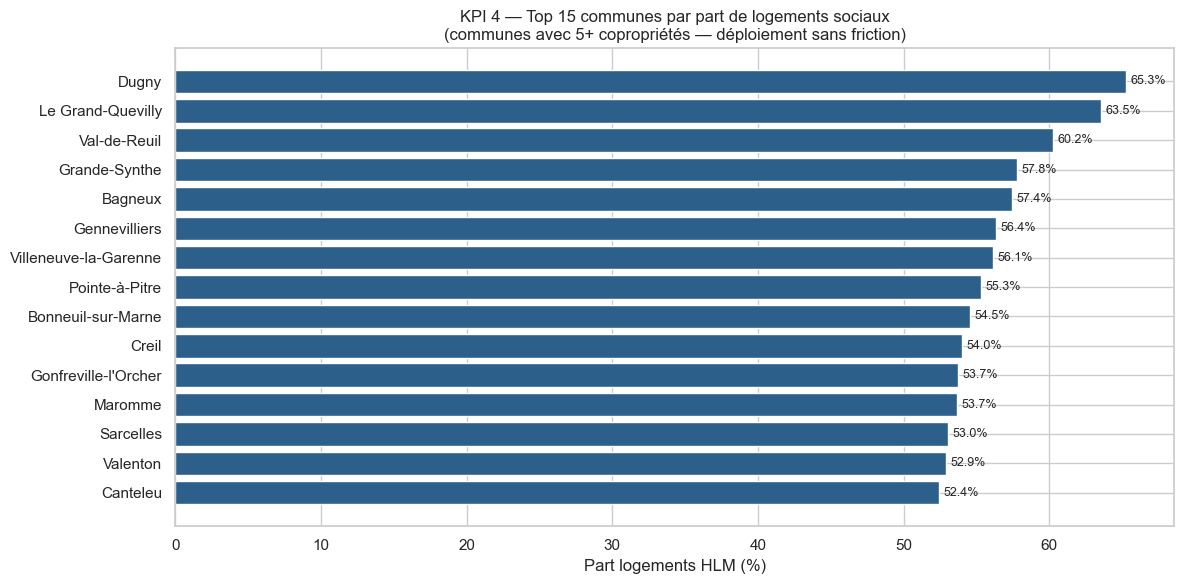

In [20]:

#  14 / KPI 4 : Part logements HLM


fig, ax = plt.subplots(figsize=(12, 6))

top15_hlm = (
    gdf_final[gdf_final['nb_coproprietes'] >= 5]
    .nlargest(15, 'part_hlm')
)

ax.barh(
    top15_hlm['nom_commune'],
    top15_hlm['part_hlm'] * 100,
    color="#2C5F8A"
)
ax.set_xlabel("Part logements HLM (%)")
ax.set_title(
    "KPI 4 — Top 15 communes par part de logements sociaux\n"
    "(communes avec 5+ copropriétés — déploiement sans friction)"
)
ax.invert_yaxis()

for i, v in enumerate(top15_hlm['part_hlm'] * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=9)

plt.tight_layout()

chemin_kpi4 = os.path.join(PROCESSED, 'kpi4_hlm.png')
plt.savefig(chemin_kpi4, dpi=150, bbox_inches='tight')
print(f"✅ KPI 4 sauvegardé : {chemin_kpi4}")
plt.show()